# Función Auxiliar (No Modificar)

In [2]:
import pandas as pd
import numpy as np
import hashlib

def generar_seed(nombre_alumno):
    """
    Genera un número entero a partir del nombre del alumno para usar como semilla.
    """
    # Crear hash md5 del nombre
    hash_object = hashlib.md5(nombre_alumno.encode())
    hash_hex = hash_object.hexdigest()
    # Convertir los primeros 8 dígitos hexadecimales a entero
    seed = int(hash_hex[:8], 16)
    return seed

def generar_dataset_alumno(nombre_alumno, n=3000, filename=None):
    """
    Genera un dataset de coches usado personalizado para un alumno.

    Args:
        nombre_alumno (str): nombre del alumno
        n (int): número de filas
        filename (str): si se proporciona, guarda CSV con este nombre
    Returns:
        pd.DataFrame
    """
    seed = generar_seed(nombre_alumno)
    np.random.seed(seed)

    # Variables numéricas
    engine_size = np.random.choice(np.arange(1.0, 3.6, 0.1), size=n)
    horsepower = (engine_size * 70 + np.random.randint(-15,15,size=n)).astype(int)
    weight = (engine_size * 500 + np.random.randint(-50,50,size=n)).astype(int)
    fuel_consumption = (4 + engine_size*2 + np.random.rand(n)*0.5).round(1)
    age = np.random.randint(0,16,size=n)
    doors = np.random.choice([3,5], size=n)

    # Variables categóricas
    brands = ["Ford","Volkswagen","Toyota","BMW","Renault","Peugeot","Audi","Fiat",
              "Hyundai","Mercedes","Seat","Opel","Volvo","Skoda","Kia"]
    brand = np.random.choice(brands, size=n)

    fuel_type = np.random.choice(["gasoline","diesel","hybrid"], size=n)
    countries = ["Germany","France","Japan","Italy","Spain","Sweden","South Korea","Czech Republic"]
    country = np.random.choice(countries, size=n)

    # Columna constante
    dealer_id = np.ones(n) * 101  # nombre ambiguo, no indicar que es constante

    # Precio aproximado
    price = (2000 + horsepower*80 + engine_size*1000 - age*500 + np.random.randint(-1000,1000,size=n)).astype(int)

    # Crear DataFrame
    df = pd.DataFrame({
        "engine_size": engine_size,
        "horsepower": horsepower,
        "weight": weight,
        "fuel_consumption": fuel_consumption,
        "age": age,
        "doors": doors,
        "brand": brand,
        "fuel_type": fuel_type,
        "country": country,
        "dealer_id": dealer_id,
        "price": price
    })

    # Introducir nulos aleatorios (~5%)
    n_nulos = n // 20
    df.loc[np.random.choice(df.index, size=n_nulos, replace=False), "horsepower"] = np.nan
    df.loc[np.random.choice(df.index, size=n_nulos, replace=False), "fuel_consumption"] = np.nan

    # Guardar CSV si se proporciona filename
    if filename:
        df.to_csv(filename, index=False)
        print(f"CSV generado para {nombre_alumno}: {filename}")

    return df


# PROGRAMACIÓN DE INTELIGENCIA ARTIFICIAL

**Duración:** 110 minutos  
**Entorno:** Google Colab  
**Librerías permitidas:** numpy, pandas, matplotlib, scikit-learn

🚫 No se permite el uso de otras librerías de ML ni AutoML.

## Objetivo
Desarrollar una aplicación de IA que prediga el precio de vehículos de segunda mano a partir de sus características.
El alumno deberá analizar los datos, decidir qué transformaciones aplicar, entrenar un modelo de regresión y evaluar su rendimiento, justificando cada decisión.

In [3]:
nombre_alumno = "Juan Sebastián Vélez Arias"

In [1]:
generar_dataset_alumno(nombre_alumno, n=3000, filename="used_cars_fp.csv")

NameError: name 'generar_dataset_alumno' is not defined

## 🔹 CELDA 1 – Importación de librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

## 🔹 CELDA 2 – Carga del dataset (5 puntos)

Tareas:
1. Cargar el dataset `used_cars_fp.csv` en un DataFrame llamado `df`
2. Mostrar las 5 primeras filas
3. Mostrar información general del dataset

In [3]:
# TODO: Cargar el dataset
df = pd.read_csv("used_cars_fp.csv")

In [5]:
df

,engine_size,horsepower,weight,fuel_consumption,age,doors,brand,fuel_type,country,dealer_id,price
0,2.1,141.0,1002,8.6,8,3,Hyundai,hybrid,Spain,101.0,12225
1,2.3,171.0,1166,8.9,3,5,Seat,hybrid,Czech Republic,101.0,16384
2,2.0,137.0,1020,8.4,5,5,Renault,hybrid,Spain,101.0,12927
3,1.6,116.0,814,7.6,3,3,Opel,diesel,Germany,101.0,11433
4,2.9,196.0,1417,10.2,12,5,Seat,gasoline,Sweden,101.0,15268
...,...,...,...,...,...,...,...,...,...,...,...
2995,3.5,231.0,1789,11.4,1,5,BMW,hybrid,Spain,101.0,24171
2996,3.1,218.0,1500,10.2,4,3,Audi,diesel,Italy,101.0,20696
2997,3.1,220.0,1513,10.5,2,3,Kia,hybrid,Germany,101.0,22195
2998,1.6,110.0,779,7.5,12,3,Mercedes,hybrid,Germany,101.0,5703


In [6]:
# TODO: Mostrar las primeras filas
df.head()
# TODO: Mostrar información del dataset
df.info()
df.describe()
df.sort_values(by="price")

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   engine_size       3000 non-null   float64
 1   horsepower        2850 non-null   float64
 2   weight            3000 non-null   int64  
 3   fuel_consumption  2850 non-null   float64
 4   age               3000 non-null   int64  
 5   doors             3000 non-null   int64  
 6   brand             3000 non-null   str    
 7   fuel_type         3000 non-null   str    
 8   country           3000 non-null   str    
 9   dealer_id         3000 non-null   float64
 10  price             3000 non-null   int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 257.9 KB


,engine_size,horsepower,weight,fuel_consumption,age,doors,brand,fuel_type,country,dealer_id,price
822,1.0,61.0,460,6.5,14,3,Peugeot,diesel,Japan,101.0,90
1176,1.0,67.0,509,6.3,15,5,Peugeot,hybrid,Spain,101.0,96
49,1.1,65.0,550,6.5,15,3,Skoda,hybrid,Sweden,101.0,174
505,1.1,68.0,500,6.5,15,3,Hyundai,hybrid,Spain,101.0,184
446,1.0,58.0,513,6.1,13,3,Fiat,hybrid,Japan,101.0,270
...,...,...,...,...,...,...,...,...,...,...,...
356,3.5,253.0,1727,11.3,1,3,Seat,diesel,Sweden,101.0,25691
857,3.5,256.0,1795,11.3,2,5,Ford,gasoline,France,101.0,25709
2541,3.5,244.0,1710,11.3,0,3,Opel,hybrid,Sweden,101.0,25827
1309,3.4,249.0,1724,11.0,0,5,Toyota,hybrid,South Korea,101.0,26071


## 🔹 CELDA 3 – Análisis exploratorio de datos (15 puntos)

Tareas:
1. Identificar columnas numéricas y categóricas.
2. Detectar valores nulos y columnas que podrían no aportar información.
3. Eliminar columnas que no sean útiles.

Incluye comentarios justificando tus decisiones.

In [7]:
# TODO: Identificar columnas numéricas y categóricas
col_num = df.select_dtypes(include=['number']).columns
col_cate = df.select_dtypes(include=['object', 'category']).columns

for col in col_num:
    unicos = df[col].nunique()
    print(f"Columna {col} tiene {unicos} valores únicos.")

print(list(col_num))
print(list(col_cate))

Columna engine_size tiene 26 valores únicos.
Columna horsepower tiene 205 valores únicos.
Columna weight tiene 1201 valores únicos.
Columna fuel_consumption tiene 56 valores únicos.
Columna age tiene 16 valores únicos.
Columna doors tiene 2 valores únicos.
Columna dealer_id tiene 1 valores únicos.
Columna price tiene 2763 valores únicos.
['engine_size', 'horsepower', 'weight', 'fuel_consumption', 'age', 'doors', 'dealer_id', 'price']
['brand', 'fuel_type', 'country']


C:\Users\Vespertino\AppData\Local\Temp\ipykernel_9676\3824456327.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_cate = df.select_dtypes(include=['object', 'category']).columns


In [8]:
# TODO: Detectar valores nulos
print(df.isna().sum()) # conteo de nulso por cada columna 
print(df.isna().mean() * 100 ) # porcentaje de nulos 
# Niveles de limpieza 

engine_size           0
horsepower          150
weight                0
fuel_consumption    150
age                   0
doors                 0
brand                 0
fuel_type             0
country               0
dealer_id             0
price                 0
dtype: int64
engine_size         0.0
horsepower          5.0
weight              0.0
fuel_consumption    5.0
age                 0.0
doors               0.0
brand               0.0
fuel_type           0.0
country             0.0
dealer_id           0.0
price               0.0
dtype: float64


In [9]:
# Rellenar con le media 
df.prueba = df.copy()
print(df['engine_size'].min())
print(df['horsepower'].min())
# Esto crea exactamente lo que dibujaste: una lista de valores por grupo
print(df.prueba.groupby('engine_size')['horsepower'].apply(list))
print(df.prueba.groupby('engine_size')['horsepower'].mean())
#df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
#df['fuel_consumption'] = df['fuel_consumption'].fillna(df['fuel_consumption'].mean)
# Rellenar con la media con el mismo tamaño del motor 
#df['horsepower'] = df['horsepower'].fillna(df.groupby('engine_size')['horsepower'].transform('mean'))
#df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

1.0
55.0
engine_size
1.0    [74.0, 71.0, 58.0, 69.0, 76.0, 59.0, 77.0, 72....
1.1    [65.0, 75.0, 82.0, 69.0, 81.0, 78.0, 77.0, 77....
1.2    [80.0, 87.0, 84.0, 91.0, 96.0, 93.0, 87.0, 93....
1.3    [99.0, 103.0, 88.0, 82.0, 95.0, 81.0, 84.0, na...
1.4    [100.0, 87.0, 97.0, 104.0, 87.0, 91.0, 97.0, 8...
1.5    [109.0, 117.0, 104.0, 117.0, 116.0, 90.0, 116....
1.6    [116.0, 110.0, 120.0, 103.0, 100.0, 107.0, 105...
1.7    [115.0, 104.0, 113.0, 108.0, 105.0, 114.0, 111...
1.8    [129.0, 125.0, 120.0, 119.0, 117.0, 128.0, 113...
1.9    [134.0, 132.0, 126.0, nan, 124.0, 120.0, 119.0...
2.0    [137.0, 151.0, 125.0, 134.0, 130.0, 130.0, 139...
2.1    [141.0, 139.0, 158.0, 137.0, 133.0, 136.0, 133...
2.2    [167.0, 168.0, 143.0, 155.0, nan, 145.0, 159.0...
2.3    [171.0, 164.0, 157.0, 166.0, 169.0, 155.0, 148...
2.4    [174.0, 176.0, 173.0, 162.0, 158.0, 156.0, 169...
2.5    [179.0, nan, 162.0, 187.0, 186.0, 177.0, 179.0...
2.6    [190.0, 194.0, 191.0, 196.0, 192.0, 196.0, 190...
2.7    [17

C:\Users\Vespertino\AppData\Local\Temp\ipykernel_9676\2172039016.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.prueba = df.copy()


In [15]:
# TODO: Detectar columnas no informativas


Columnas constantes: ['dealer_id']


In [10]:
# varianza cero 
no_informativas_constantes = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Columnas constantes: {no_informativas_constantes}")
# identificadores únicos (alta cardinalidad)
umbral_id = 0.95
alta_cardinalidad = [col for col in df.select_dtypes(include=['object']).columns if (df[col].nunique() / len(df)) > umbral_id]
print(f"Posibles Identificadores (no útiles para modelos): {alta_cardinalidad}")

# columnas con exceso de nulos 
umbral_nulos = 0.5
muchos_nulos = df.columns[df.isnull().mean() > umbral_nulos].tolist()
print(f"Columnas con más del 50% nulos: {muchos_nulos}")

Columnas constantes: ['dealer_id']
Posibles Identificadores (no útiles para modelos): []
Columnas con más del 50% nulos: []


C:\Users\Vespertino\AppData\Local\Temp\ipykernel_9676\3409111593.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  alta_cardinalidad = [col for col in df.select_dtypes(include=['object']).columns if (df[col].nunique() / len(df)) > umbral_id]


In [4]:
# TODO: Eliminar columnas no útiles
df = df.drop(columns=['dealer_id']) 

## 🔹 CELDA 4 – Visualización de datos (10 puntos)

Tareas:
Explora visualmente la relación entre variables y el precio de los vehículos.
Realiza al menos dos gráficos utilizando solo matplotlib, incluyendo:

1. Scatter plot de horsepower vs price

2. Boxplot simple de brand vs price

Incluye comentarios breves explicando lo que observas y cómo podría afectar al modelo de regresión.

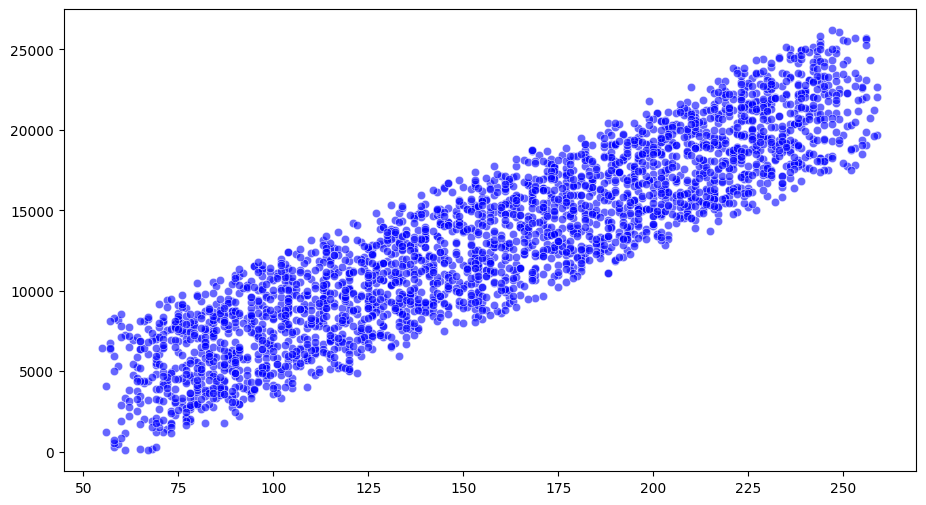

In [38]:
# TODO: Crear un gráfico con matplotlib
plt.figure(figsize=(11, 6))
df_plot = df.dropna(subset=['horsepower', 'price']) # código opcional 
plt.scatter(
    df_plot['horsepower'],
    df_plot['price'],
    alpha=0.6,
    color='blue',
    edgecolors='white',
    linewidth=0.5
)

{'whiskers': [<matplotlib.lines.Line2D at 0x1f3d101aa50>,
 'caps': [<matplotlib.lines.Line2D at 0x1f3d101acf0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x1f3d105d590>,
 'medians': [<matplotlib.lines.Line2D at 0x1f3d101af90>,
 'fliers': [<matplotlib.lines.Line2D at 0x1f3d101b0e0>,
 'means': []}

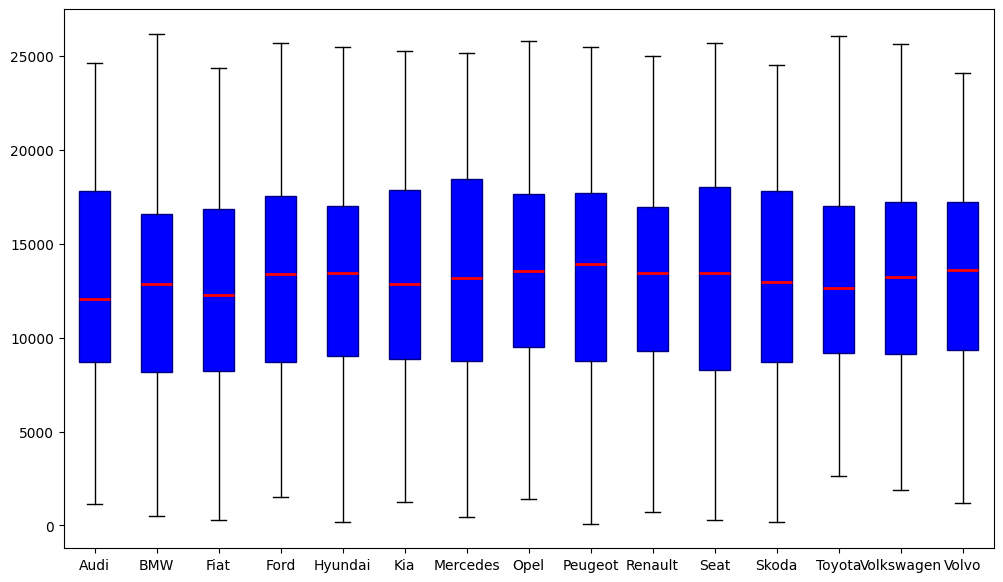

In [43]:
plt.figure(figsize=(12, 7))

marcas = sorted(df['brand'].unique())
datos_por_marca = [df[df['brand']  == marca ]['price'] for marca in marcas]

plt.boxplot(datos_por_marca,
           tick_labels=marcas,
           patch_artist=True,
           boxprops=dict(facecolor='blue', color='navy'),
           medianprops=dict(color='red', linewidth=2))

## 🔹 CELDA 5 – División del conjunto de datos (5 puntos)

Dividir en entrenamiento (80%) y test (20%).

In [5]:
from sklearn.model_selection import train_test_split
# TODO: Dividir los datos en train y testa
X = df.drop('price', axis=1) # partimos solo la columna price del resto del dataset
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Verificación de experto
print(f"📊 Total de registros: {len(df)}")
print(f"✅ Entrenamiento (80%): {X_train.shape[0]} filas")
print(f"🧪 Test (20%): {X_test.shape[0]} filas")

📊 Total de registros: 3000
✅ Entrenamiento (80%): 2400 filas
🧪 Test (20%): 600 filas


## 🔹 CELDA 6 – Flujo de procesamiento(imputación,escalado,codificación) de datos (20 puntos)

Tareas:
1. Separar variables predictoras (`X`) y objetivo (`y`).
2. Crear flujos para:
   - Variables numéricas: imputación (media) + estandarización
   - Variables categóricas: imputación (valor más frecuente) + codificación



In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# TODO: Separar X e y
target = 'price'
X = df.drop(columns = [target])
y = df[target]
# TODO: Definir columnas numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
# TODO: Crear pipelines de preprocesamiento
num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output=False))
])
# TODO: Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)
print("✅ Pipeline de preprocesamiento creado con éxito.")
print(f"Propiedades: {len(num_cols)} numéricas y {len(cat_cols)} categóricas.")

✅ Pipeline de preprocesamiento creado con éxito.
Propiedades: 6 numéricas y 3 categóricas.


C:\Users\sebastian.velez\AppData\Local\Temp\ipykernel_6780\4208720428.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns


## 🔹 CELDA 7 – Optimización del conjunto de variables (10 puntos)

Algunas variables numéricas pueden estar fuertemente correlacionadas entre sí, generando información redundante.
Analiza la relación entre las variables y decide cómo simplificar el conjunto de variables para el modelo.
Ajusta tu selección de variables o combinaciones de manera que mantengas al menos un 80% de la variabilidad de los datos.
Justifica tu elección con un gráfico o tabla que muestre las relaciones y explica cómo afectaría al modelo.

In [9]:
from sklearn.decomposition import PCA

X_train_processed = preprocessor.fit_transform(X_train)
X_train_processed_num = X_train_processed[:, :len(num_cols)]
# TODO: Aplicar reducción de dimensionalidad si lo consideras
pca = PCA(n_components = 0.80) #mantener el 80% de la varianza 
X_pca = pca.fit_transform(X_train_processed_num)

print(f"Originalmente teniamos {len(num_cols)} col númericas.")
print(f"Ahora tenemos {pca.n_components_} componentes para el 80% de la varianza ")
# TODO: Justificar la decisión

'''
El PCA se usa para reducir la dimensionalidad de aquellos datasets con muchas col, tener un rango de 5-10 se consdiran pocas. Por lo que no seria muy recomendable aplicar el PCA.

'''

Originalmente teniamos 6 col númericas.
Ahora tenemos 2 componentes para el 80% de la varianza 


'\nEl PCA se usa para reducir la dimensionalidad de aquellos datasets con muchas col, tener un rango de 5-10 se consdiran pocas. Por lo que no seria muy recomendable aplicar el PCA.\n\n'

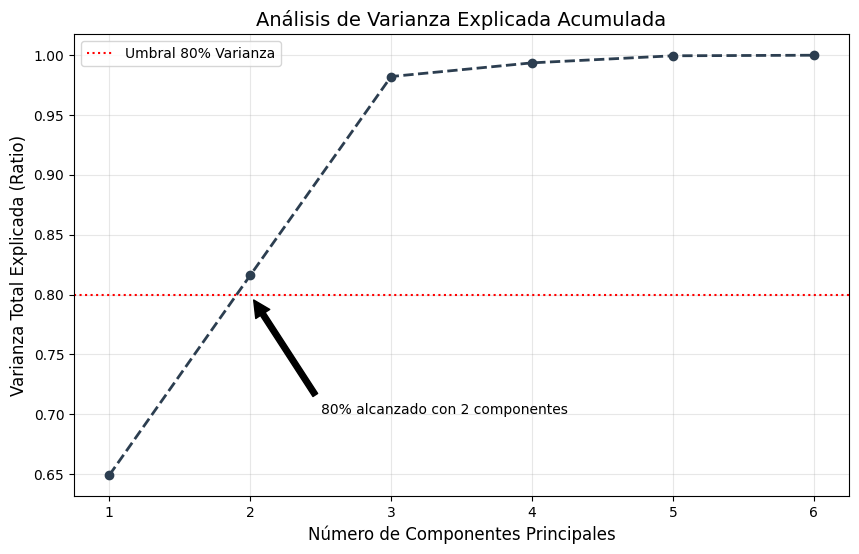

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Preprocesar solo las columnas numéricas (usando el pipeline de la Celda 6)
# Primero ajustamos y transformamos X_train
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Como ColumnTransformer pone las numéricas primero (según tu definición en Celda 6)
# Extraemos solo las columnas que corresponden a num_cols
X_num_scaled = X_train_preprocessed[:, :len(num_cols)]

# 2. Calcular PCA para todas las componentes posibles
pca_test = PCA().fit(X_num_scaled)
varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

# 3. Visualización Profesional
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 
         marker='o', linestyle='--', color='#2c3e50', linewidth=2)

# Línea de referencia del 80%
plt.axhline(y=0.80, color='r', linestyle=':', label='Umbral 80% Varianza')

plt.title('Análisis de Varianza Explicada Acumulada', fontsize=14)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Total Explicada (Ratio)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Anotación para tu justificación
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
plt.annotate(f'80% alcanzado con {n_80} componentes', 
             xy=(n_80, 0.80), xytext=(n_80+0.5, 0.70),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

## 🔹 CELDA 8 – Modelo (20 puntos)

El objetivo es predecir el precio de un vehículo a partir de sus características.
Decide qué método o algoritmo utilizarías para estimar un valor numérico continuo y justifica tu elección.
Integra este método en un flujo de procesamiento que transforme los datos y produzca la predicción.

In [11]:
# TODO: Crear pipeline completo con regresión
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# 1. Creamos el Pipeline final: Preprocesamiento + Modelo
# El preprocessor es el que ya definiste (imputación, escalado, one-hot)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 2. Entrenamos el flujo completo con los datos de la Celda 5
model_pipeline.fit(X_train, y_train)

# 3. Realizamos predicciones
y_pred = model_pipeline.predict(X_test)

print("✅ Modelo entrenado y predicciones generadas.")
# TODO: Entrenar el modelo
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"El error medio de mis predicciones es de: {mae:.2f} €")

✅ Modelo entrenado y predicciones generadas.
El error medio de mis predicciones es de: 573.35 €


In [15]:
from sklearn.linear_model import LinearRegression

# Creamos el Pipeline con Regresión Lineal
model_linear = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenamos
model_linear.fit(X_train, y_train)

# 1. Extraer los nombres de las columnas tras el preprocesamiento
# Las numéricas mantienen su nombre, las categóricas se expandieron con el One-Hot
cat_features = model_linear.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
nombres_columnas = list(num_cols) + list(cat_features)

# 2. Obtener los coeficientes (Pesos)
pesos = model_linear.named_steps['regressor'].coef_
precio_base = model_linear.named_steps['regressor'].intercept_

# 3. Crear un DataFrame para verlo bonito
df_importancia = pd.DataFrame({'Característica': nombres_columnas, 'Peso (€)': pesos})
df_importancia = df_importancia.sort_values(by='Peso (€)', ascending=False)

print(f"🏠 Precio Base (Intercepto): {precio_base:.2f} €")
print("\n📋 Impacto de cada variable en el precio:")
print(df_importancia)

# Generamos las inferencias (predicciones)
y_pred = model_linear.predict(X_test)

🏠 Precio Base (Intercepto): 13138.69 €

📋 Impacto de cada variable en el precio:
            Característica     Peso (€)
0              engine_size  3459.887894
1               horsepower  1362.926740
2                   weight   227.557319
29     country_South Korea    89.697335
18            brand_Toyota    85.567252
6               brand_Audi    76.852239
20             brand_Volvo    73.273671
11               brand_Kia    70.333961
3         fuel_consumption    53.694868
15           brand_Renault    41.450831
16              brand_Seat    35.394793
24  country_Czech Republic    21.398946
25          country_France    15.879451
23        fuel_type_hybrid    10.239368
26         country_Germany     8.686307
9               brand_Ford     6.368211
27           country_Italy    -1.919321
22      fuel_type_gasoline    -4.974950
21        fuel_type_diesel    -5.264419
10           brand_Hyundai    -9.167091
31          country_Sweden   -18.017293
5                    doors   -19.892035

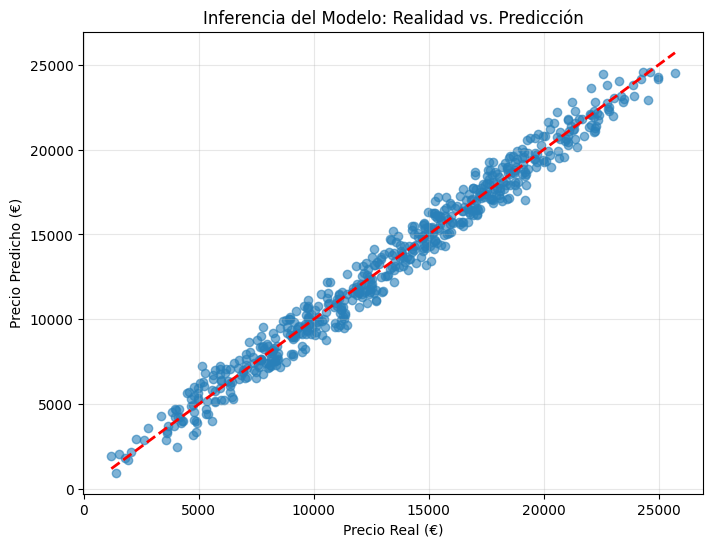

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#2980b9')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Precio Real (€)')
plt.ylabel('Precio Predicho (€)')
plt.title('Inferencia del Modelo: Realidad vs. Predicción')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
comparativa = pd.DataFrame({'Real': y_test, 'Predicción': y_pred.round(2)})
comparativa['Error (€)'] = (comparativa['Real'] - comparativa['Predicción']).abs()
print(comparativa.head(10))

       Real  Predicción  Error (€)
1801  19320    18837.17     482.83
1190  12507    11999.15     507.85
1817   9202     9158.87      43.13
251   22196    22276.43      80.43
2505  21103    21084.18      18.82
1117   8377     7298.61    1078.39
1411  17851    17680.25     170.75
2113  14942    14718.95     223.05
408    8853     9218.08     365.08
2579  22793    22408.30     384.70


## 🔹 CELDA 9 – Evaluación del modelo (10 puntos)

Evaluar el rendimiento en test utilizando las métricas que mejor apliquen.

In [16]:
# TODO: Realizar predicciones sobre test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Realizar predicciones sobre el conjunto de test (el 20% que reservamos)
y_pred = model_linear.predict(X_test)

# 2. Calcular métricas fundamentales
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 3. Mostrar resultados de forma clara
print("📊 Rendimiento del Modelo de Regresión Lineal:")
print(f"🔹 MAE (Error Medio Absoluto): {mae:.2f} €")
print(f"🔹 RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} €")
print(f"🔹 R² (Coeficiente de Determinación): {r2:.4f}")
# TODO: Calcular métricas

📊 Rendimiento del Modelo de Regresión Lineal:
🔹 MAE (Error Medio Absoluto): 634.04 €
🔹 RMSE (Raíz del Error Cuadrático Medio): 777.59 €
🔹 R² (Coeficiente de Determinación): 0.9795


## 🔹 CELDA 10 – Predicción de nuevos datos (10 puntos)

Se proporciona un vehículo nuevo:

```python
nuevo_vehiculo = pd.DataFrame([{
    "engine_size": 2.0,
    "horsepower": 150,
    "weight": 1300,
    "fuel_consumption": 6.5,
    "age": 3,
    "doors": 5,
    "brand": "Toyota",
    "fuel_type": "hybrid",
    "country": "Japan"
}])
```
Predecir el precio utilizando el modelo entrenado.

In [17]:
# TODO: Predecir el precio del nuevo vehículo
nuevo_vehiculo = pd.DataFrame([{
    "engine_size": 2.0,
    "horsepower": 150,
    "weight": 1300,
    "fuel_consumption": 6.5,
    "age": 3,
    "doors": 5,
    "brand": "Toyota",
    "fuel_type": "hybrid",
    "country": "Japan"
}])
# Realizar la predicción para el nuevo vehículo
prediccion_precio = model_linear.predict(nuevo_vehiculo)

print(f"🚗 Características del vehículo: {nuevo_vehiculo.iloc[0]['brand']} {nuevo_vehiculo.iloc[0]['engine_size']}L, {nuevo_vehiculo.iloc[0]['age']} años.")
print(f"💰 El precio estimado por el modelo es de: {prediccion_precio[0]:,.2f} €")

🚗 Características del vehículo: Toyota 2.0L, 3 años.
💰 El precio estimado por el modelo es de: 14,011.28 €


## Observaciones
- El alumno debe razonar y justificar cada decisión, no solo ejecutar código.

In [87]:
import pandas as pd
from io import StringIO

datos = """nombre,edad,ciudad,venta,ano
Ana,23,Madrid,1,500,2025
Ana,23,Madrid,1,500,2023
Ana,23,Madrid,1,66500,2023
Ana,23,Madrid,1,5500,2023
Ana,23,Madrid,1,500,2024
Ana,23,Madrid,1,4500,2024
Ana,23,Madrid,1,500,2024
Ana,23,Madrid,1,3500,2024
Ana,23,Madrid,1,500,2024
Ana,23,Madrid,1,500,2024
Ana,23,Madrid,1,500,2024
Ana,23,Madrid,1,500,2024
Ana,23,Madrid,1,700,2024
Ana,23,Madrid,1,700,2025
Ana,23,Madrid,1,700,2025
Ana,23,Madrid,1,700,2025
"""
df = pd.read_csv(StringIO(datos))
df.describe()
#print(df["edad"].isna().sum())
#df["edad"] = df["edad"].fillna(df["edad"].mean()).astype(int)
"""
queremos rellenar los valores string vacios con la moda
"""
moda_ciudad = df["ciudad"].mode()[0]
df["ciudad"] = df["ciudad"].fillna(moda_ciudad)

"""
umbral_nulos = 0.1 # % de nulos
muchos_nulos = df.columns[df.isnull().mean() > umbral_nulos].tolist()
"""
#df = df.drop(columns=["id"])
print(df)
"""
for col in df["ciudad"]:
    print(col[0])

print(df["ciudad"])
print(df["ciudad"][0])
print(df["ciudad"][0][0])
"""

     nombre    edad  ciudad  venta   ano
Ana      23  Madrid       1    500  2025
Ana      23  Madrid       1    500  2023
Ana      23  Madrid       1  66500  2023
Ana      23  Madrid       1   5500  2023
Ana      23  Madrid       1    500  2024
Ana      23  Madrid       1   4500  2024
Ana      23  Madrid       1    500  2024
Ana      23  Madrid       1   3500  2024
Ana      23  Madrid       1    500  2024
Ana      23  Madrid       1    500  2024
Ana      23  Madrid       1    500  2024
Ana      23  Madrid       1    500  2024
Ana      23  Madrid       1    700  2024
Ana      23  Madrid       1    700  2025
Ana      23  Madrid       1    700  2025
Ana      23  Madrid       1    700  2025


'\nfor col in df["ciudad"]:\n    print(col[0])\n\nprint(df["ciudad"])\nprint(df["ciudad"][0])\nprint(df["ciudad"][0][0])\n'

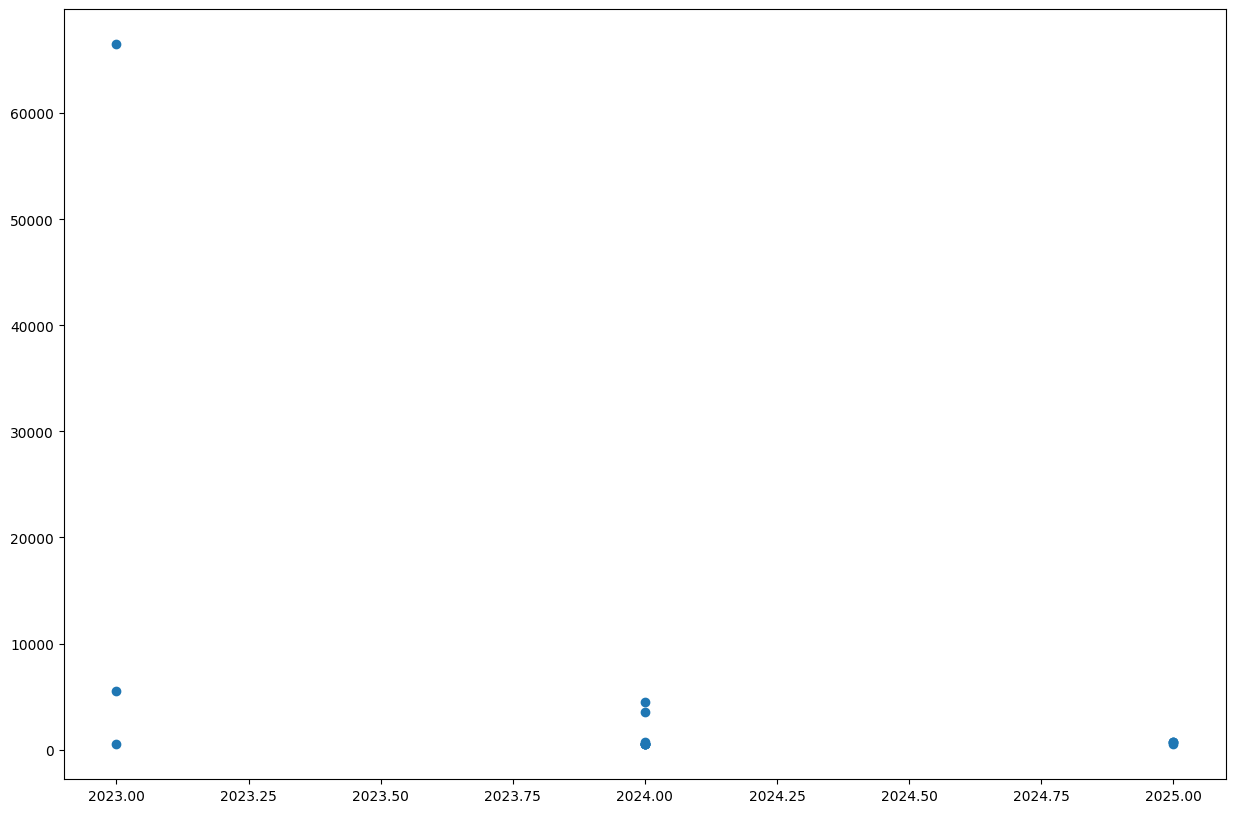

In [89]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
type(plt)
plt.scatter(
    df["ano"],
    df["venta"],
)


<BarContainer object of 16 artists>

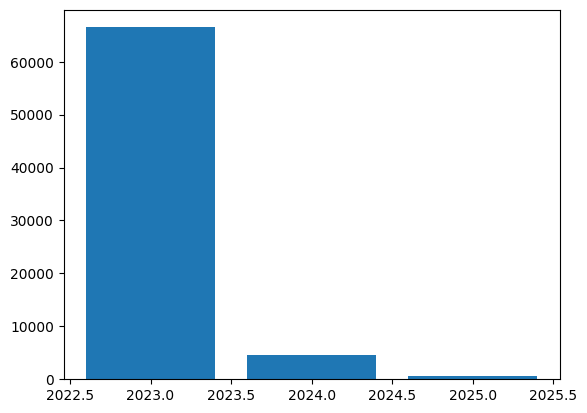

In [91]:
plt.bar(df["ano"], df["venta"])